## PARTE 1 — Creación del índice mediante el wizard (Import data)

Esta parte es documental: seguir el wizard en el portal para crear el índice. Entregar en este archivo las capturas y explicaciones.

Pasos (portal):
1. En el recurso de **Azure AI Search** seleccionar **Import data**.
2. Elegir escenario: **RAG** (no agentic retrieval).
3. Conectar a **Azure Blob Storage** (seleccionar contenedor con documentos). Autenticación por Managed Identity o clave.
4. En vectorización elegir proveedor (Azure OpenAI / Foundry) y deployment de embeddings.
5. Revisar la inferencia del esquema y ajustar campos si hace falta.
6. Finalizar: el wizard crea Data Source, Index, Skillset (si se activó enrichment), Indexer y Knowledge Store opcional.

### Capturas y explicaciones que hay que adjuntar



### **ÍNDICE (Index schema)**: capturar la definición del índice creado.

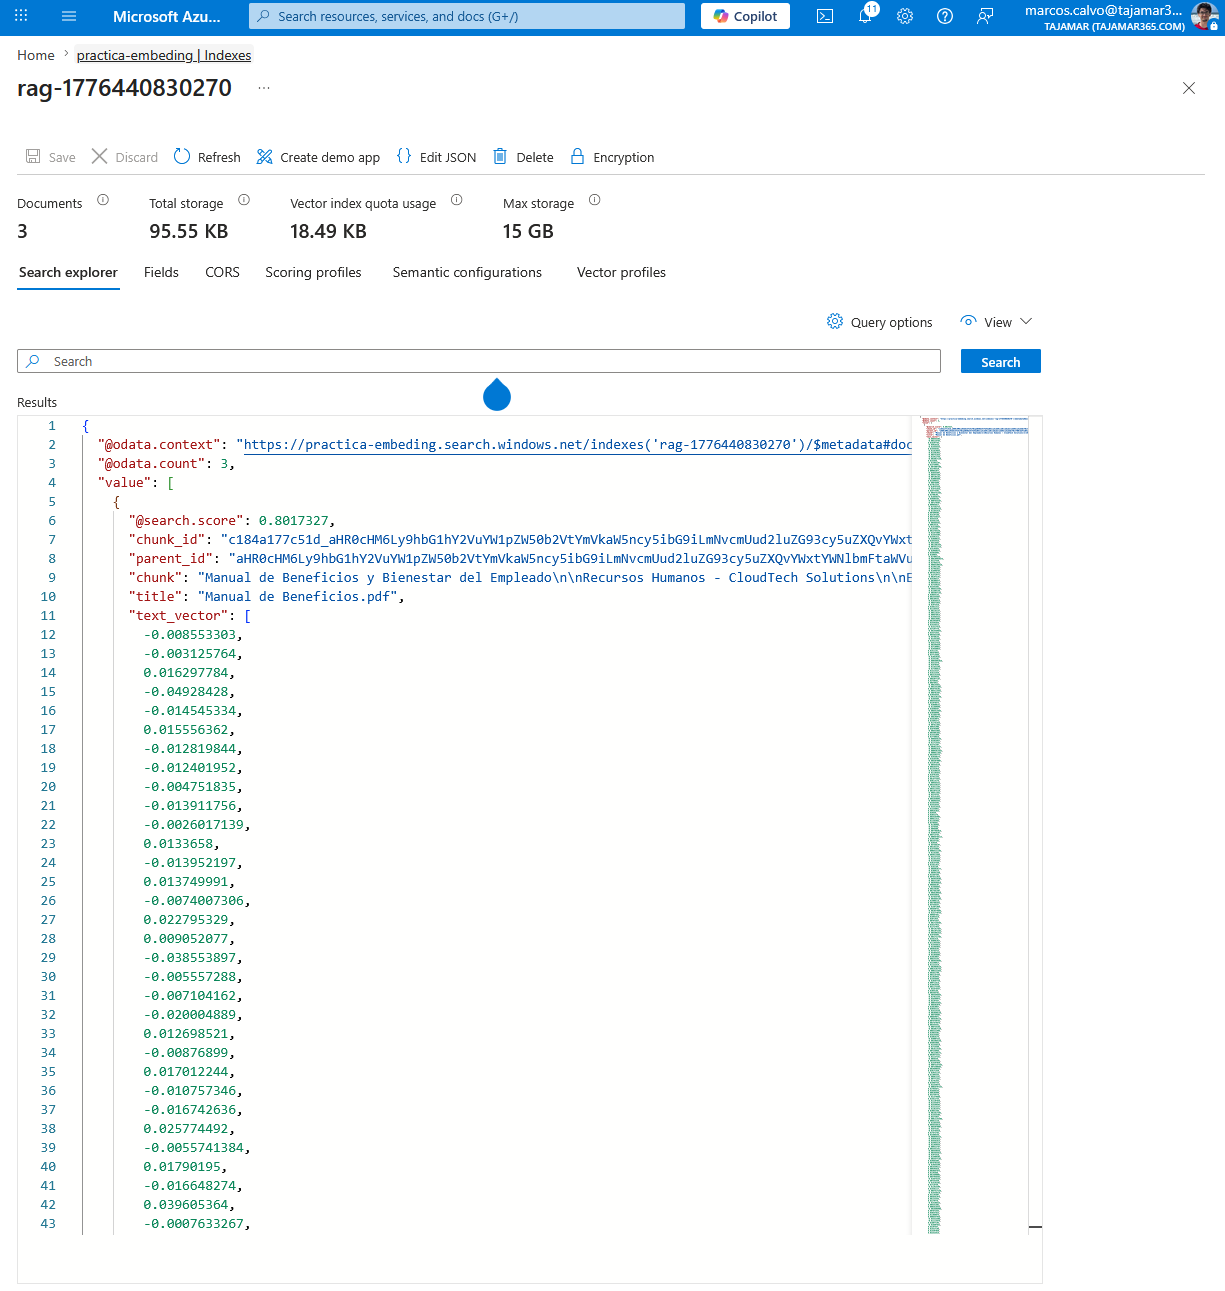

#### Explicación:
El Index schema define la estructura de datos de nuestro índice de búsqueda. Es equivalente a un esquema de base de datos: especifica qué campos se van a almacenar, qué tipo de datos contienen y cómo se comportarán durante la búsqueda. 

En nuestro caso, el índice puede contener campos como `metadata_storage_path`, `content`, `text`, entre otros. Cada campo tiene propiedades importantes:
- **Retrievable**: si el campo se devuelve en los resultados de búsqueda
- **Searchable**: si se puede buscar dentro de ese campo
- **Filterable**: si se puede usar para filtrar resultados
- **Sortable**: si se puede ordenar por ese campo
- **Facetable**: si se puede usar para agrupar resultados

El wizard infiere automáticamente el esquema según los documentos cargados, pero es importante revisar que los campos críticos (como `content`) tengan las propiedades correctas para nuestra búsqueda RAG.

---

### **SEMANTIC CONFIGURATION**: captura del objeto semántico creado. Explicar qué es y cómo está configurado.

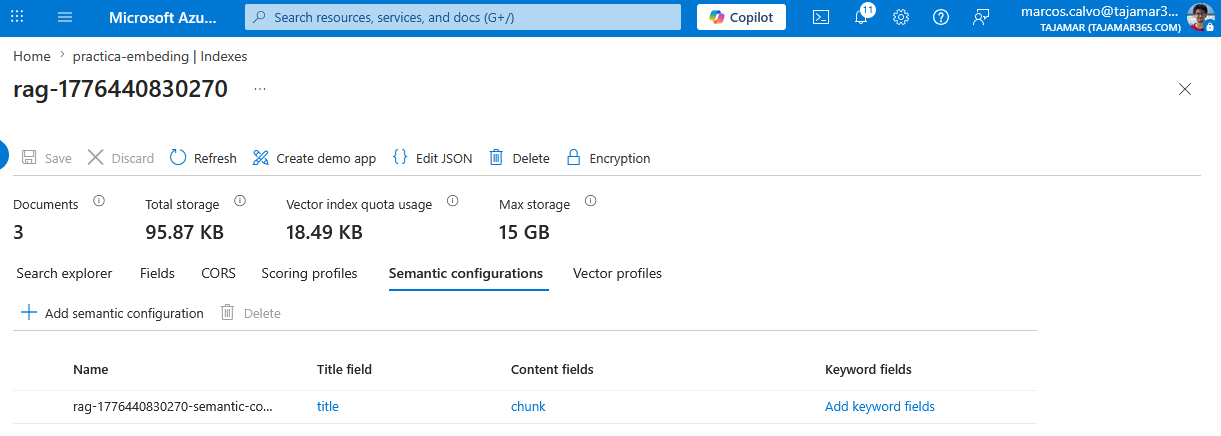

#### Explicación:
La Semantic Configuration es un objeto que habilita búsqueda semántica en Azure AI Search. A diferencia de la búsqueda por palabras clave tradicional, la búsqueda semántica utiliza modelos de lenguaje para entender el **sentido y significado** de las consultas, no solo las palabras exactas.

Esta configuración define:
- **Nombre de la configuración**: identificador único (ej: "default")
- **Title field**: el campo que se usa como título en los resultados (normalmente el más descriptivo)
- **Content fields**: campos prioritarios donde se busca el significado


Con la Semantic Configuration activa, cuando un usuario búsqueda "problemas con embeddings", el sistema entiende que también es relevante una página sobre "dificultades con vectores", aunque no contenga exactamente esas palabras.

---

### **VECTOR PROFILE**: captura de la sección `Algorithm` y `Vectorizer` del índice. Explicar cada una de ellas y cómo están configuradas

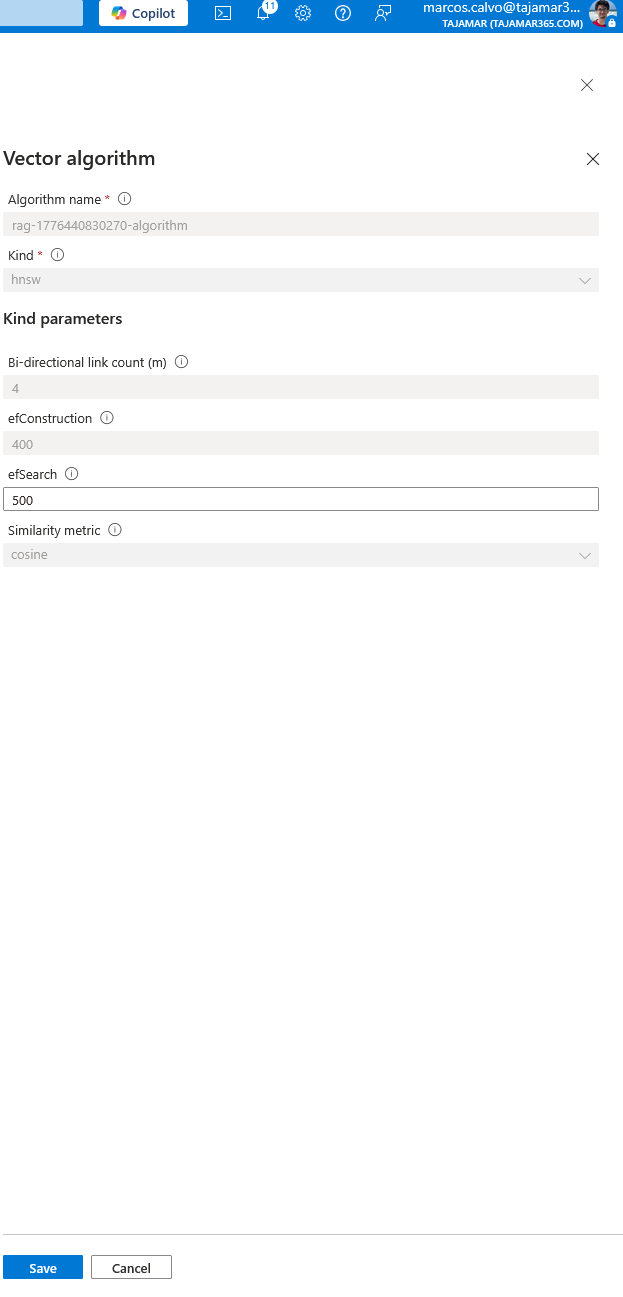

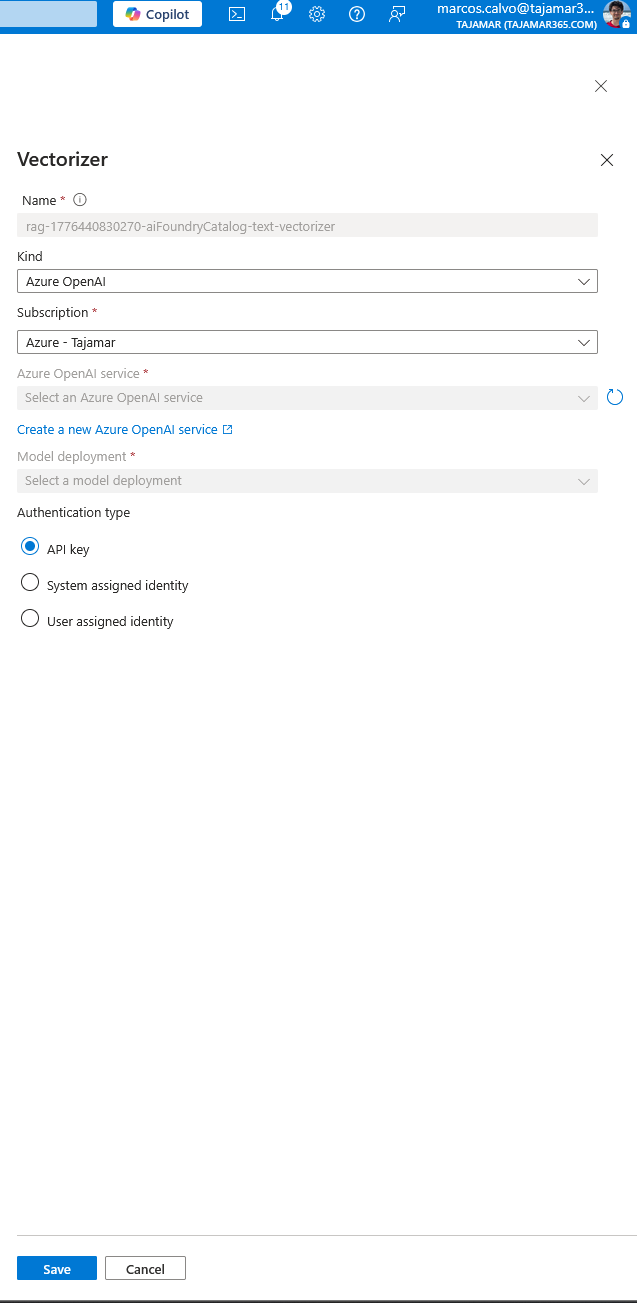

#### Explicación:

El **Vector Profile** configura cómo el índice almacena y busca vectores (embeddings). Tiene dos componentes principales:

**1. Algorithm (Algoritmo de búsqueda vectorial):**
Define la técnica para encontrar vectores similares rápidamente. Generalmente usa algoritmos como:
- **HNSW** (Hierarchical Navigable Small World): crea una estructura jerárquica que permite búsquedas aproximadas muy rápidas
- Define parámetros como `m` (conexiones por nodo) y `efConstruction` (esfuerzo durante construcción)

**2. Vectorizer (Generador de embeddings):**
Especifica cómo convertir texto en vectores. En nuestro caso:
- **AzureOpenAI** o **Foundry**: el proveedor que genera los embeddings
- **Deployment name**: qué modelo de embedding se usa (ej: "text-embedding-3-small" con dimensión 1536)
- Define el modelo que transforma el texto en representación numérica

Juntos, permiten que documentos y consultas se conviertan en vectores numéricos, y que se encuentren similitudes mediante cálculos de distancia en el espacio vectorial.

---

### **SKILLSET**: captura del skillset generado por el wizard. Explicar qué es y los pasos que contiene

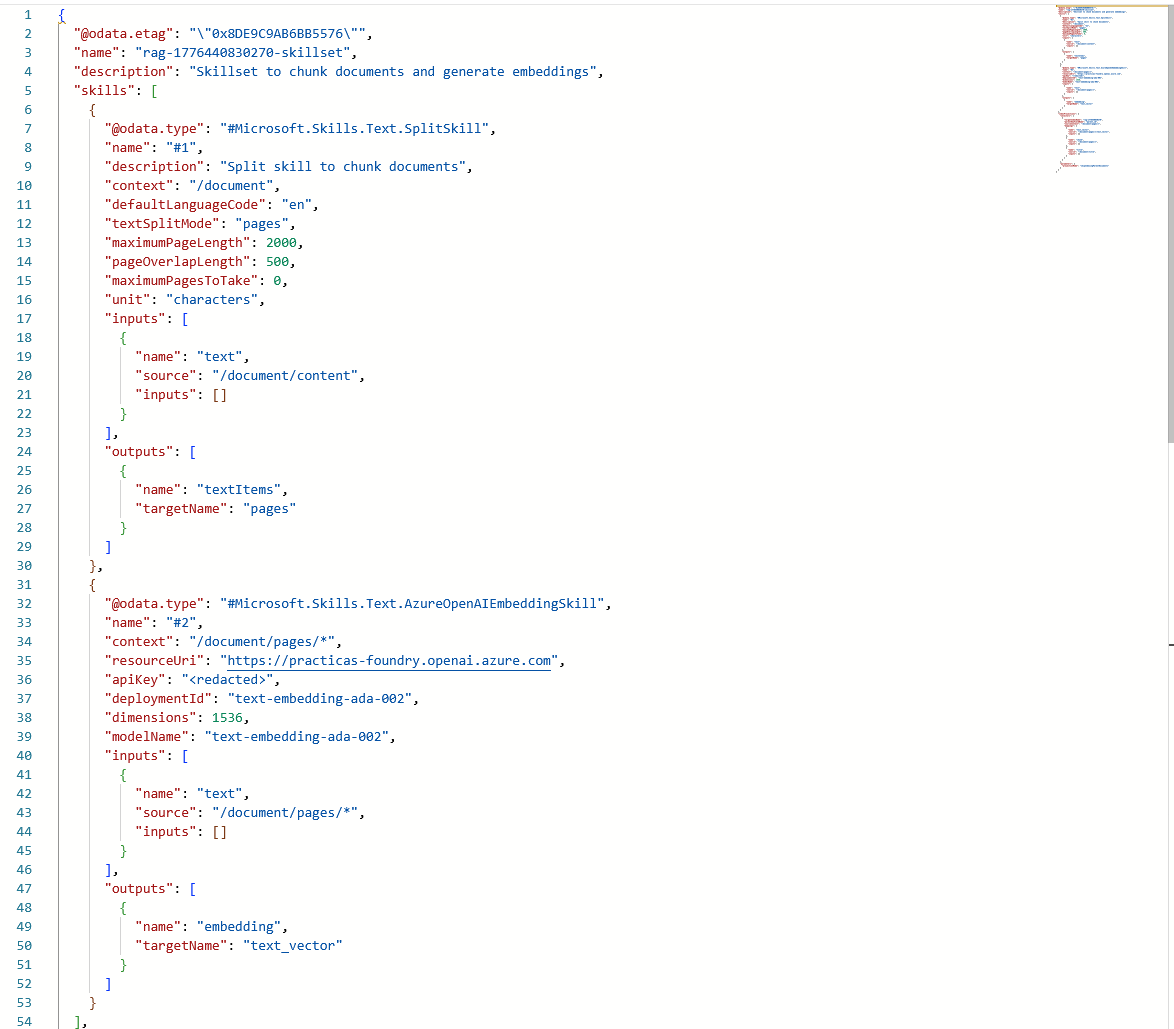
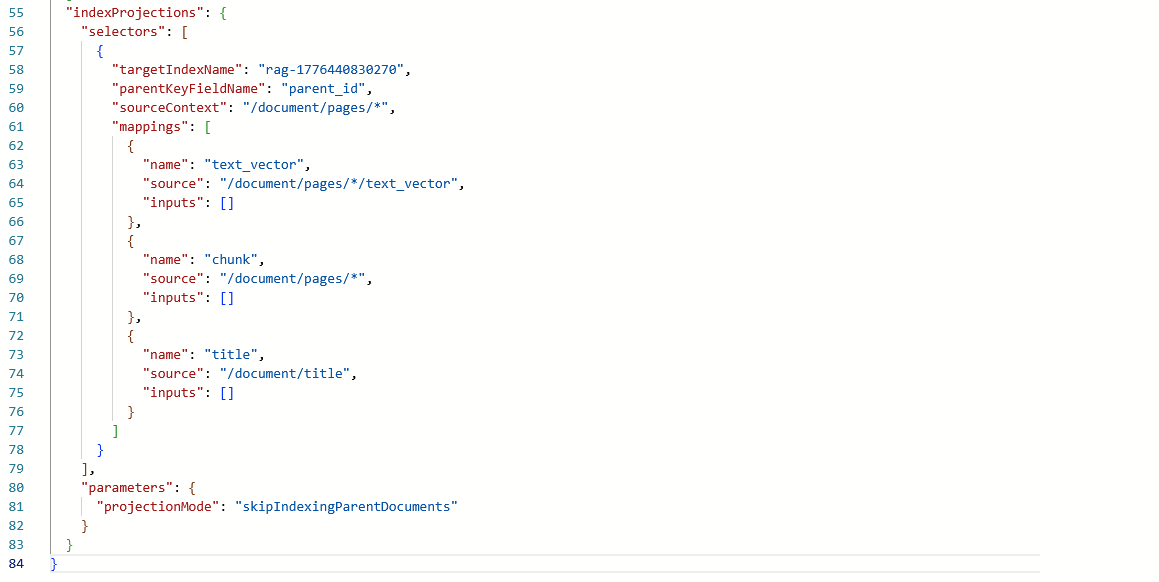

#### Explicación:
Un Skillset es un **pipeline de enriquecimiento** que procesa los documentos antes de indexarlos. Es una secuencia de transformaciones que optimizan el contenido para búsqueda.

El skillset generado por el wizard típicamente contiene habilidades como:
- **Text Split / Chunking**: divide documentos grandes en fragmentos manejables
- **Azure OpenAI Embedding Skill**: genera vectores para el contenido usando el modelo configurado
- **Language Detection**: detecta el idioma del documento (útil para procesamiento multilingüe)
- **Text Analysis Skills**: (opcional) extrae entidades, detecta sentimientos, etc.

**Flujo de procesamiento:**
El documento entra → se divide en chunks → se detecta idioma → se generan embeddings para cada chunk → se enriquecen con metadatos → se envían al índice.

Esta enriquecimiento es crucial para RAG porque asegura que cada fragmento de contenido tenga su correspondiente vector, permitiendo búsquedas vectoriales precisas en el índice.